# Khám phá bộ câu hỏi đánh giá generated_qa_30

Notebook này chỉ đọc `data/eval/generated_qa_30.json`, không tải model và không gọi GPU.
Dùng để xem nhanh bộ câu hỏi, loại câu hỏi, sản phẩm nguồn và keyword kỳ vọng.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
QA_PATH = ROOT / "data" / "eval" / "generated_qa_30.json"

qa = json.loads(QA_PATH.read_text(encoding="utf-8"))
rows = []
for item in qa:
    source = item.get("source_product", {})
    rows.append({
        "id": item.get("id"),
        "type": item.get("type"),
        "question": item.get("question"),
        "expected_answer": item.get("expected_answer"),
        "product_id": source.get("product_id"),
        "ten_san_pham": source.get("ten_san_pham"),
        "source_file": source.get("source_file"),
        "keyword_count": len(item.get("expected_keywords", [])),
    })

df = pd.DataFrame(rows)
print("Số câu hỏi:", len(df))
df.head(10)

Số câu hỏi: 30


,id,type,question,expected_answer,product_id,ten_san_pham,source_file,keyword_count
0,qa001,goi_y_san_pham,"Cây ăn trái có biểu hiện Hoa khô, rụng hàng lo...",Sản phẩm đúng: KẼM BORON 50.000ppm. Công dụng:...,sp1,KẼM BORON 50.000ppm,data/Thuoc_Metadata/phan_bon.json,7
1,qa002,cach_dung,NPK 20-20-15 TE dùng như thế nào?,NPK 20-20-15 TE dùng theo hướng dẫn: Bón gốc 2...,sp2,NPK 20-20-15 TE,data/Thuoc_Metadata/phan_bon.json,3
2,qa003,gia,Giá tham khảo của DAP 18-46-0 là bao nhiêu?,Giá tham khảo của DAP 18-46-0 là 1.100.000 - 1...,sp3,DAP 18-46-0,data/Thuoc_Metadata/phan_bon.json,2
3,qa004,thanh_phan,Thành phần chính của KALI CLORUA KCl 60% là gì?,Thành phần chính: kali_huu_hieu_k2o: 60%; dang...,sp4,KALI CLORUA KCl 60%,data/Thuoc_Metadata/phan_bon.json,3
4,qa005,an_toan,Khi dùng CANXI BO MAX cần lưu ý an toàn gì?,Lưu ý an toàn: Không pha với phân chứa phospha...,sp5,CANXI BO MAX,data/Thuoc_Metadata/phan_bon.json,3
5,qa006,goi_y_san_pham,"Rau màu có biểu hiện Rễ ít, đất chai cứng, cây...",Sản phẩm đúng: HUMIC ACID 70%. Công dụng: Cải ...,sp6,HUMIC ACID 70%,data/Thuoc_Metadata/phan_bon.json,8
6,qa007,cach_dung,SEAWEED AMINO 30 dùng như thế nào?,SEAWEED AMINO 30 dùng theo hướng dẫn: Pha 15-2...,sp7,SEAWEED AMINO 30,data/Thuoc_Metadata/phan_bon.json,4
7,qa008,gia,Giá tham khảo của NPK 16-16-8 + TE là bao nhiêu?,Giá tham khảo của NPK 16-16-8 + TE là 650.000 ...,sp8,NPK 16-16-8 + TE,data/Thuoc_Metadata/phan_bon.json,2
8,qa009,thanh_phan,Thành phần chính của MAGIE KẼM LƯU HUỲNH là gì?,Thành phần chính: mgo: 16%; zn: 5%; s: 12%; ph...,sp9,MAGIE KẼM LƯU HUỲNH,data/Thuoc_Metadata/phan_bon.json,5
9,qa010,an_toan,Khi dùng PHÂN BÓN LÁ 10-55-10 cần lưu ý an toà...,Lưu ý an toàn: Không lạm dụng khi cây đang suy...,sp10,PHÂN BÓN LÁ 10-55-10,data/Thuoc_Metadata/phan_bon.json,3


,type,count
0,goi_y_san_pham,6
1,cach_dung,6
2,gia,6
3,thanh_phan,6
4,an_toan,6


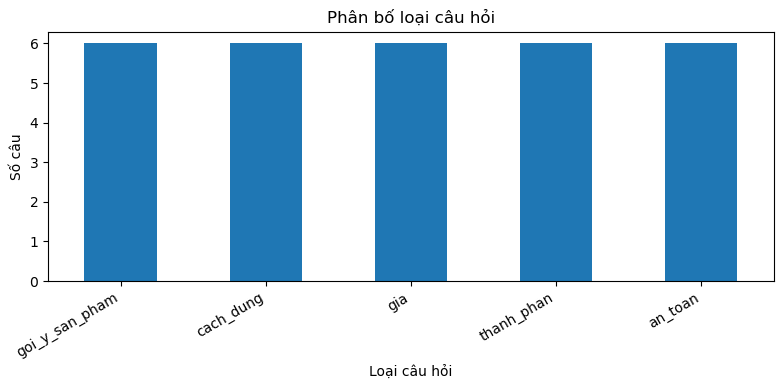

In [2]:
type_counts = df["type"].value_counts().rename_axis("type").reset_index(name="count")
display(type_counts)

ax = type_counts.plot.bar(x="type", y="count", legend=False, figsize=(8, 4))
ax.set_title("Phân bố loại câu hỏi")
ax.set_xlabel("Loại câu hỏi")
ax.set_ylabel("Số câu")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [3]:
display(
    df[["id", "type", "question", "ten_san_pham", "keyword_count"]]
    .sort_values(["type", "id"])
    .head(30)
)

,id,type,question,ten_san_pham,keyword_count
4,qa005,an_toan,Khi dùng CANXI BO MAX cần lưu ý an toàn gì?,CANXI BO MAX,3
9,qa010,an_toan,Khi dùng PHÂN BÓN LÁ 10-55-10 cần lưu ý an toà...,PHÂN BÓN LÁ 10-55-10,3
14,qa015,an_toan,Khi dùng TRICHODERMA NANO cần lưu ý an toàn gì?,TRICHODERMA NANO,3
19,qa020,an_toan,Khi dùng NPK 12-12-17+2MgO cần lưu ý an toàn gì?,NPK 12-12-17+2MgO,3
24,qa025,an_toan,Khi dùng CANXI NITRAT 15.5-0-0+26CaO cần lưu ý...,CANXI NITRAT 15.5-0-0+26CaO,3
29,qa030,an_toan,Khi dùng PHÂN DƠI HỮU CƠ cần lưu ý an toàn gì?,PHÂN DƠI HỮU CƠ,3
1,qa002,cach_dung,NPK 20-20-15 TE dùng như thế nào?,NPK 20-20-15 TE,3
6,qa007,cach_dung,SEAWEED AMINO 30 dùng như thế nào?,SEAWEED AMINO 30,4
11,qa012,cach_dung,NPK 30-10-10 dùng như thế nào?,NPK 30-10-10,4
16,qa017,cach_dung,SIÊU KALI BO dùng như thế nào?,SIÊU KALI BO,4


In [4]:
selected_id = "qa001"
item = next(x for x in qa if x["id"] == selected_id)
print("QUESTION:")
print(item["question"])
print("\nEXPECTED ANSWER:")
print(item["expected_answer"])
print("\nEXPECTED PRODUCT IDS:")
print(item.get("expected_product_ids"))
print("\nEXPECTED KEYWORDS:")
print(item.get("expected_keywords")[:20])

QUESTION:
Cây ăn trái có biểu hiện Hoa khô, rụng hàng loạt, trái non dễ rụng. Nên dùng sản phẩm nào và vì sao?

EXPECTED ANSWER:
Sản phẩm đúng: KẼM BORON 50.000ppm. Công dụng: Tăng khả năng thụ phấn, đậu trái, hạn chế rụng hoa và trái non. Cách dùng: Pha 500g cho phuy 200-250 lít nước, phun đều hai mặt lá. Lưu ý: Không pha chung với thuốc có tính kiềm mạnh, bảo quản nơi khô ráo. Giá tham khảo: 75.000 - 90.000 VND.

EXPECTED PRODUCT IDS:
['sp1']

EXPECTED KEYWORDS:
['KẼM BORON 50.000ppm', 'Tăng khả năng thụ phấn', 'đậu trái', 'hạn chế rụng hoa và trái non', 'Pha 500g cho phuy 200-250 lít nước, phun đều hai mặt lá', '500g', '200-250 lít']
